In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/main_done_cumulative_lrg.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/main_done_cumulative_lrg.fits'))
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

344684


In [4]:
# Julien's bad fibers list
# bad_fibers = np.array(Table.read('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
bad_fibers = np.append(bad_fibers, np.arange(2663, 2680+1))  # fibers affected by the CCD z5 defect
bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
bad_fibers = np.unique(bad_fibers)
print(len(bad_fibers), 'bad fibers')
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]

205 bad fibers


In [5]:
cat['MEAN_X'], cat['MEAN_Y'] = 0., 0.
for fiber in np.unique(cat['FIBER']):
    mask = cat['FIBER']==fiber
    cat['MEAN_X'][mask] = np.mean(cat['FIBERASSIGN_X'][mask])
    cat['MEAN_Y'][mask] = np.mean(cat['FIBERASSIGN_Y'][mask])

In [6]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # # ZDONE fibers
# # mask = cat['ZDONE']==1
# # print('ZDONE   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))

FIBERSTATUS    5098 339586 0.014790358705364914
No data    0 339586 0.0
Min depth    7570 332016 0.022291849487316908


In [7]:
# # WISE and MEDIUM masks
# maskbits = [8, 9, 11]
# mask_clean = np.ones(len(cat), dtype=bool)
# for bit in maskbits:
#     mask_clean &= (cat['MASKBITS'] & 2**bit)==0
# print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
# cat = cat[mask_clean]

In [8]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [9]:
mask_gal = cat['SPECTYPE']=='GALAXY'
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
mask_qso = cat['SPECTYPE']=='QSO'

# Force the very low-z objects to have SPECTYPE=STAR
cat['SPECTYPE'][mask_star] = 'STAR'

In [10]:
cat['Z'][mask_gal].max()

1.699740294373923

In [11]:
mask_quality0 = cat['ZWARN']==0
mask_quality0 &= cat['DELTACHI2']>15
mask_quality0 &= cat['Z']<1.4
print(np.sum(~mask_quality0)/len(mask_quality0))

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)
print(np.sum(~mask_quality)/len(mask_quality))

# Custom cut with DELTACHI2>15
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<15)
mask_quality1 = cat['ZWARN']==0
mask_quality1 &= cat['Z']<1.4
mask_quality1 &= (~mask_remove)
print(np.sum(~mask_quality1)/len(mask_quality1))

# cat = cat[mask_quality]
# print(len(cat))

0.026004770854416655
0.023992819623150693
0.0278570912245193


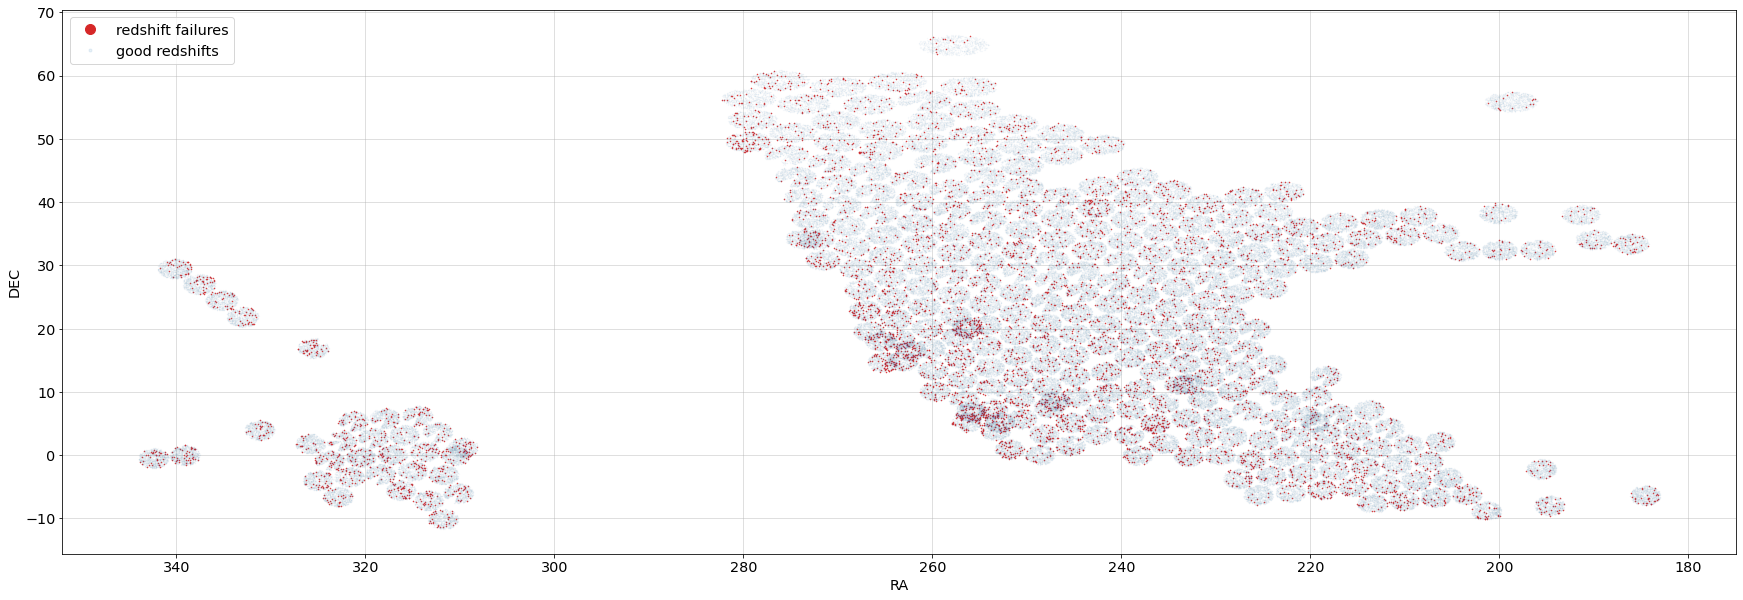

In [12]:
plt.figure(figsize=(30, 10))
plt.plot(cat['TARGET_RA'][~mask_quality], cat['TARGET_DEC'][~mask_quality], 'C3.', ms=1, label='redshift failures')
plt.plot(cat['TARGET_RA'][mask_quality], cat['TARGET_DEC'][mask_quality], 'C0.', ms=.3, alpha=0.1, label='good redshifts')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper left', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

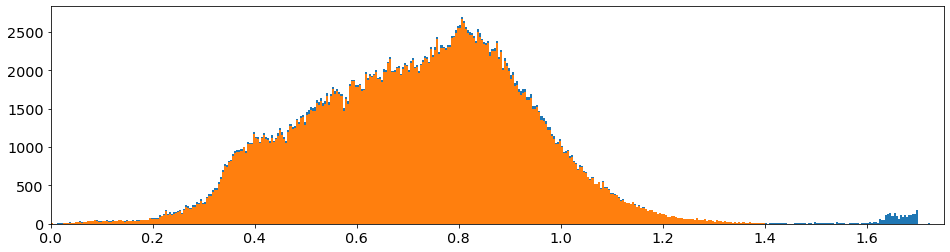

In [13]:
plt.figure(figsize=(16, 4))
plt.hist(cat['Z'][(~mask_star)], 500, log=False, range=(0, 2.))
plt.hist(cat['Z'][(~mask_star) & mask_quality1], 500, log=False, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

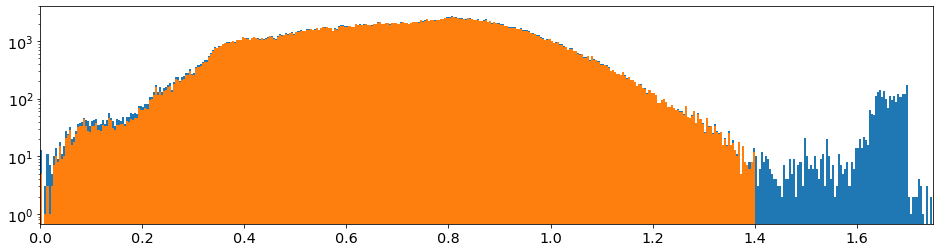

In [14]:
plt.figure(figsize=(16, 4))
plt.hist(cat['Z'][(~mask_star)], 500, log=True, range=(0, 2.))
plt.hist(cat['Z'][(~mask_star) & mask_quality1], 500, log=True, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

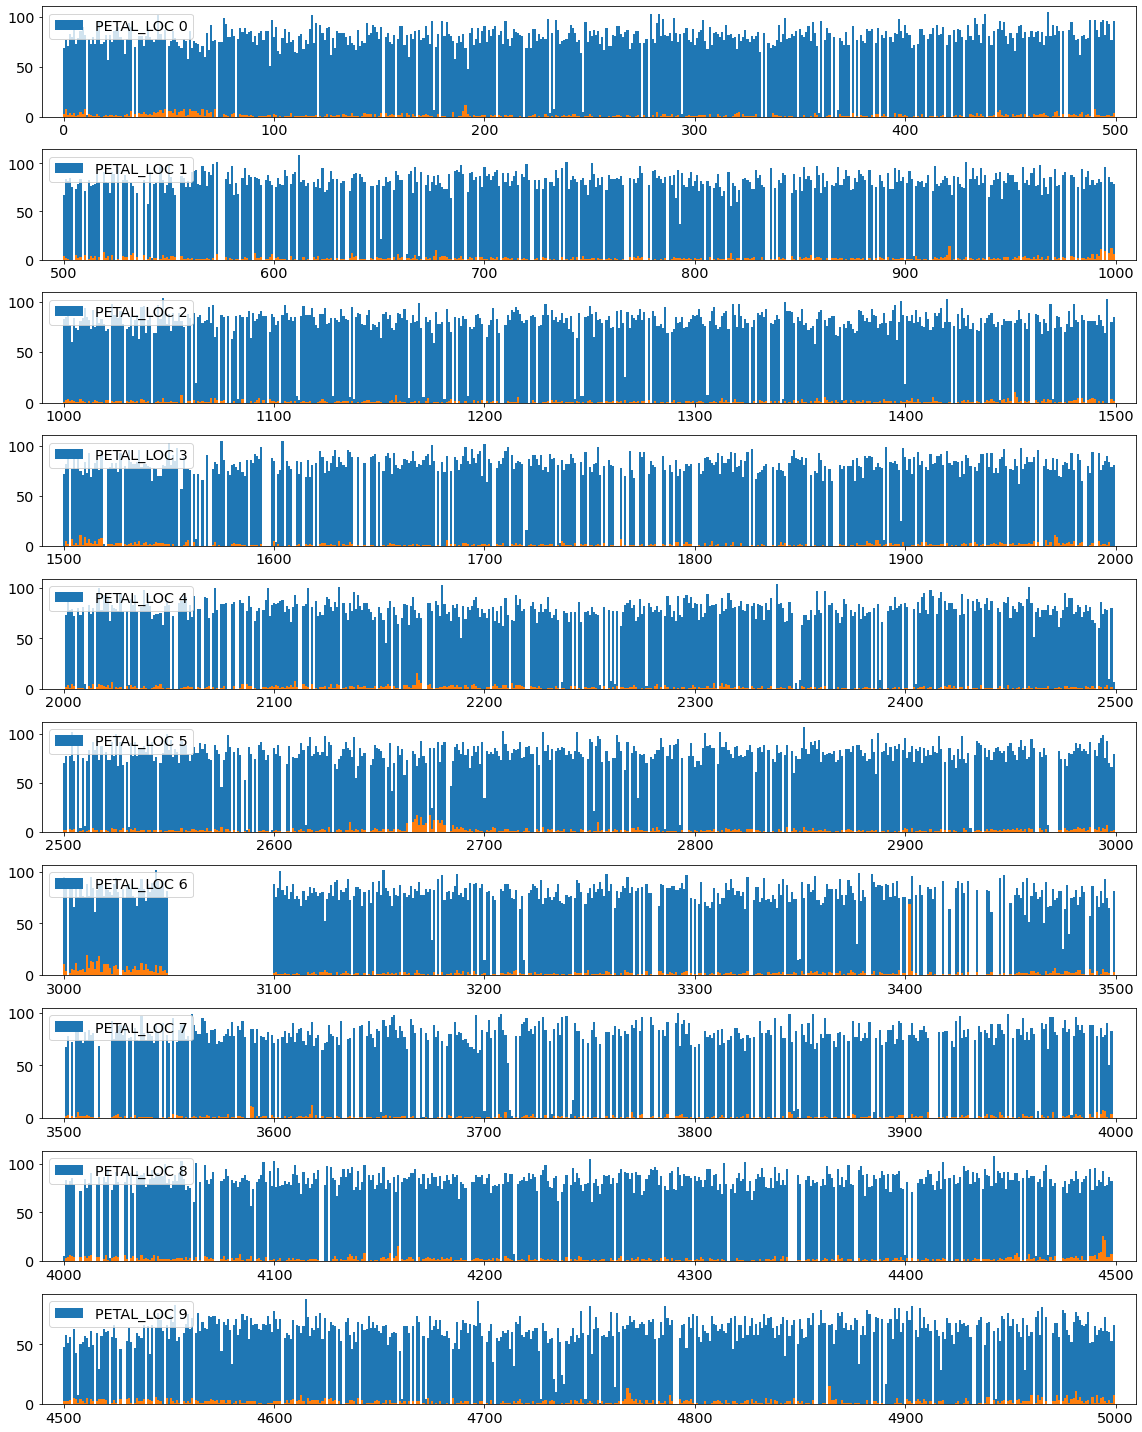

In [15]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (cat['FIBER']>fiber_min) & (cat['FIBER']<fiber_max)
    ax[index].hist(cat['FIBER'][mask], 500, range=(fiber_min, fiber_max), label='PETAL_LOC {}'.format(index))
    ax[index].hist(cat['FIBER'][mask & (~mask_quality)], 500, range=(fiber_min, fiber_max))
    ax[index].set_xlim(fiber_min-10, fiber_max+10)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

In [16]:
fiberstats = Table()
fiberstats['FIBER'], fiberstats['n_tot'] = np.unique(cat['FIBER'], return_counts=True)
fiberstats.sort('n_tot')

tt = Table()
tt['FIBER'], tt['n_fail'] = np.unique(cat['FIBER'][~mask_quality], return_counts=True)
fiberstats = join(fiberstats, tt, keys='FIBER', join_type='outer').filled(0)
fiberstats['frac_fail'] = fiberstats['n_fail']/fiberstats['n_tot']

error_floor = True

n, p = fiberstats['n_tot'].copy(), fiberstats['frac_fail'].copy()
if error_floor:
    p1 = np.maximum(p, 1/n)  # error floor
else:
    p1 = p
fiberstats['frac_fail_err'] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
fiberstats.sort('n_fail')

fiberstats

FIBER,n_tot,n_fail,frac_fail,frac_fail_err
int32,int64,int64,float64,float64
1889,78,0,0.0,0.012738064937539489
2627,88,0,0.0,0.011298885771811653
4683,55,0,0.0,0.01801577070206772
4686,51,0,0.0,0.019414657705424988
1071,97,0,0.0,0.01025600006956303
2629,69,0,0.0,0.014387350379788876
4283,78,0,0.0,0.012738064937539489
2625,77,0,0.0,0.012902406138576674
2633,84,0,0.0,0.011833688064142915


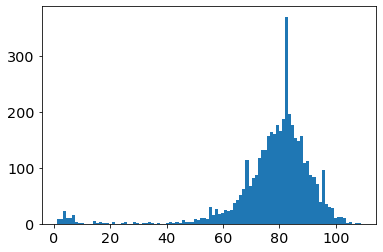

In [17]:
plt.hist(fiberstats['n_tot'], 100);

In [18]:
fiberstats['MEAN_X'], fiberstats['MEAN_Y'] = 0., 0.
for index, fiber in enumerate(fiberstats['FIBER']):
    mask = cat['FIBER']==fiber
    fiberstats['MEAN_X'][index], fiberstats['MEAN_Y'][index] = cat['MEAN_X'][mask][0], cat['MEAN_Y'][mask][0]

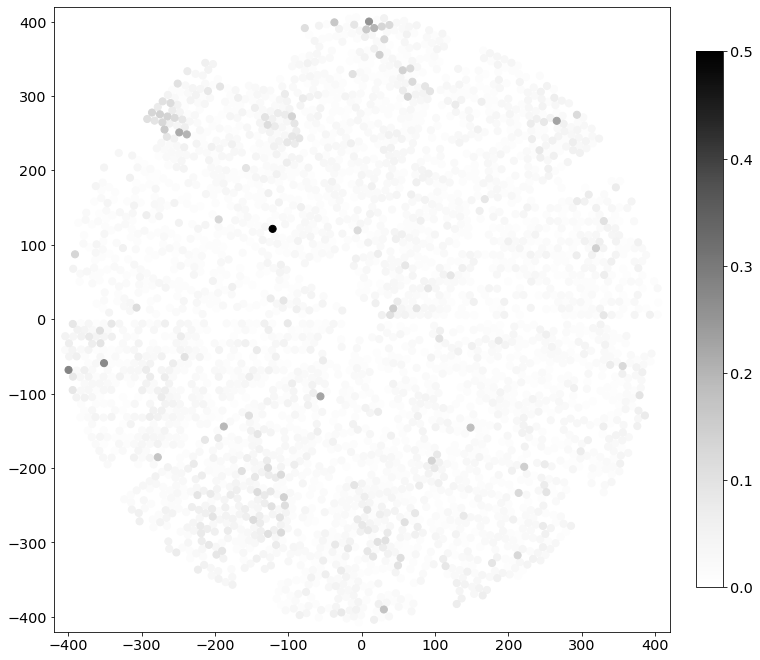

In [19]:
mask = fiberstats['n_tot']>30

plt.figure(figsize=(12, 11.5))
plt.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=fiberstats['frac_fail'][mask],
            s=50, vmin=0, vmax=0.5, cmap='Greys')
plt.axis([-420, 420, -420, 420])
plt.colorbar(fraction=0.04, pad=0.04)
# plt.axis('off')
plt.show()

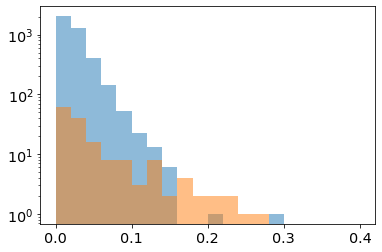

In [20]:
mask_good = (fiberstats['n_tot']>30) & (~np.in1d(fiberstats['FIBER'], bad_fibers))
mask_bad = (fiberstats['n_tot']>30) & np.in1d(fiberstats['FIBER'], bad_fibers)

plt.hist(fiberstats['frac_fail'][mask_good], 20, range=(0, 0.4), log=True, alpha=0.5)
plt.hist(fiberstats['frac_fail'][mask_bad], 20, range=(0, 0.4), log=True, alpha=0.5)
plt.show()

-------

__Flag the groups of bad fibers__

In [21]:
mask_bad1 = (fiberstats['FIBER']>=43) & (fiberstats['FIBER']<74)
mask_bad1 |= (fiberstats['FIBER']>=988) & (fiberstats['FIBER']<1000)
mask_bad1 |= (fiberstats['FIBER']>=1500) & (fiberstats['FIBER']<1520)
mask_bad1 |= (fiberstats['FIBER']>=3000) & (fiberstats['FIBER']<3050)

bad_fibers1 = np.unique(np.append(bad_fibers, fiberstats['FIBER'][mask_bad1]))
print(len(bad_fibers1), len(bad_fibers1)-len(bad_fibers))

309 104


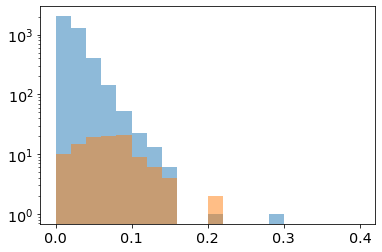

In [22]:
plt.hist(fiberstats['frac_fail'][mask_good], 20, range=(0, 0.4), log=True, alpha=0.5)
plt.hist(fiberstats['frac_fail'][mask_bad1], 20, range=(0, 0.4), log=True, alpha=0.5)
plt.show()

In [23]:
# Original list of bad fibers
mask_bad = (fiberstats['n_tot']>30) & (np.in1d(fiberstats['FIBER'], bad_fibers))
print(np.mean(fiberstats['frac_fail'][mask_bad]), np.sum(mask_bad))

mask_good = (fiberstats['n_tot']>30) & (~np.in1d(fiberstats['FIBER'], bad_fibers))
print(np.mean(fiberstats['frac_fail'][mask_good]), np.sum(mask_good))

0.05385515666503422 161
0.02307220474458744 3984


In [24]:
# Adding more bad fibers
mask_bad = (fiberstats['n_tot']>30) & (np.in1d(fiberstats['FIBER'], bad_fibers1))
print(np.mean(fiberstats['frac_fail'][mask_bad]), np.sum(mask_bad))

mask_good = (fiberstats['n_tot']>30) & (~np.in1d(fiberstats['FIBER'], bad_fibers1))
print(np.mean(fiberstats['frac_fail'][mask_good]), np.sum(mask_good))

0.0606630569215581 264
0.02179214040149846 3881


In [25]:
# The newly added bad objects
mask_bad_new = (fiberstats['n_tot']>30) & (np.in1d(fiberstats['FIBER'], bad_fibers1))
mask_bad = (fiberstats['n_tot']>30) & (np.in1d(fiberstats['FIBER'], bad_fibers))
mask = mask_bad_new & (~mask_bad)
print(np.mean(fiberstats['frac_fail'][mask]), np.sum(mask))

0.07130453207981385 103


__Flag the worst fibers__

In [26]:
# frac_fail_threshold = np.percentile(fiberstats_good['frac_fail'], 99.5)
frac_fail_threshold = 0.1

mask_good = (fiberstats['n_tot']>30) & (~np.in1d(fiberstats['FIBER'], bad_fibers1))
fiberstats_good = fiberstats[mask_good].copy()

print(frac_fail_threshold)
mask_threshold = fiberstats_good['frac_fail']>=frac_fail_threshold
print(np.sum(mask_threshold), np.sum(mask_threshold)/len(mask_threshold))
print(np.mean(fiberstats_good['frac_fail'][mask_threshold]), np.mean(fiberstats_good['frac_fail']), np.mean(fiberstats_good['frac_fail'][~mask_threshold]))
print(np.sum(fiberstats_good['n_fail'][mask_threshold])/np.sum(fiberstats_good['n_fail']))

bad_fibers2 = np.unique(np.append(bad_fibers1, fiberstats_good['FIBER'][mask_threshold]))
print(len(bad_fibers2), len(bad_fibers2)-len(bad_fibers1))

0.1
24 0.006183973202782788
0.1231815308822285 0.02179214040149846 0.021161249716630037
0.030526315789473683
333 24


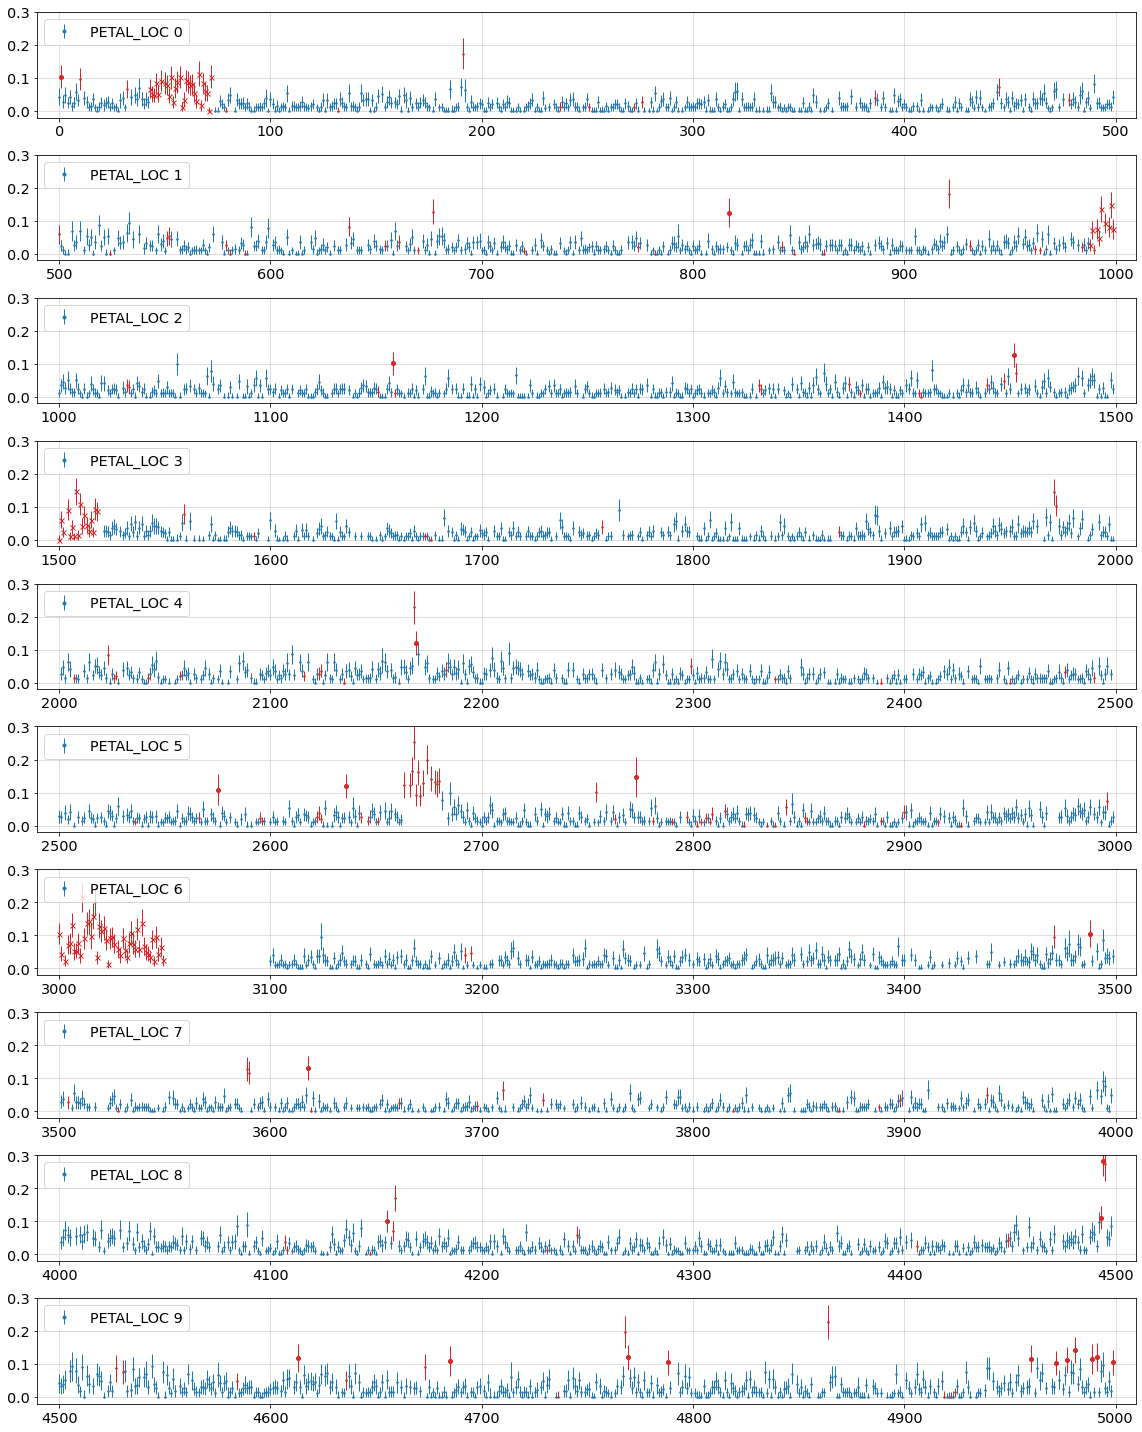

In [27]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (fiberstats['FIBER']>fiber_min) & (fiberstats['FIBER']<fiber_max)
    mask &= (fiberstats['n_tot']>30)
    mask_good = mask & (~np.in1d(fiberstats['FIBER'], bad_fibers)) & (~np.in1d(fiberstats['FIBER'], bad_fibers1)) \
                & (~np.in1d(fiberstats['FIBER'], bad_fibers2))
    mask_bad = mask & np.in1d(fiberstats['FIBER'], bad_fibers)
    mask_bad1 = mask & np.in1d(fiberstats['FIBER'], bad_fibers1) & (~mask_bad)
    mask_bad2 = mask & np.in1d(fiberstats['FIBER'], bad_fibers2) & (~mask_bad) & (~mask_bad1)
    # plt.figure(figsize=(16, 2))
    ax[index].errorbar(fiberstats['FIBER'][mask_good], fiberstats['frac_fail'][mask_good], 
                       yerr=(np.clip(fiberstats['frac_fail_err'][mask_good], None, fiberstats['frac_fail'][mask_good]), fiberstats['frac_fail_err'][mask_good]),
                       color='C0', fmt='.', ms=3, elinewidth=1, label='PETAL_LOC {}'.format(index))
    ax[index].errorbar(fiberstats['FIBER'][mask_bad], fiberstats['frac_fail'][mask_bad],
                   yerr=(np.clip(fiberstats['frac_fail_err'][mask_bad], None, fiberstats['frac_fail'][mask_bad]), fiberstats['frac_fail_err'][mask_bad]),
                   color='C3', fmt='.', ms=3, elinewidth=1)
    ax[index].errorbar(fiberstats['FIBER'][mask_bad1], fiberstats['frac_fail'][mask_bad1],
                   yerr=(np.clip(fiberstats['frac_fail_err'][mask_bad1], None, fiberstats['frac_fail'][mask_bad1]), fiberstats['frac_fail_err'][mask_bad1]),
                   color='C3', fmt='x', ms=5, elinewidth=1)
    ax[index].errorbar(fiberstats['FIBER'][mask_bad2], fiberstats['frac_fail'][mask_bad2],
                   yerr=(np.clip(fiberstats['frac_fail_err'][mask_bad2], None, fiberstats['frac_fail'][mask_bad2]), fiberstats['frac_fail_err'][mask_bad2]),
                   color='C3', fmt='o', ms=4, elinewidth=1)
    ax[index].grid(alpha=0.5)
    ax[index].set_yticks([0., 0.1, 0.2, 0.3], minor=False)
    ax[index].set_ylim(-0.02, 0.3)
    ax[index].set_xlim(fiber_min-10, fiber_max+10)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

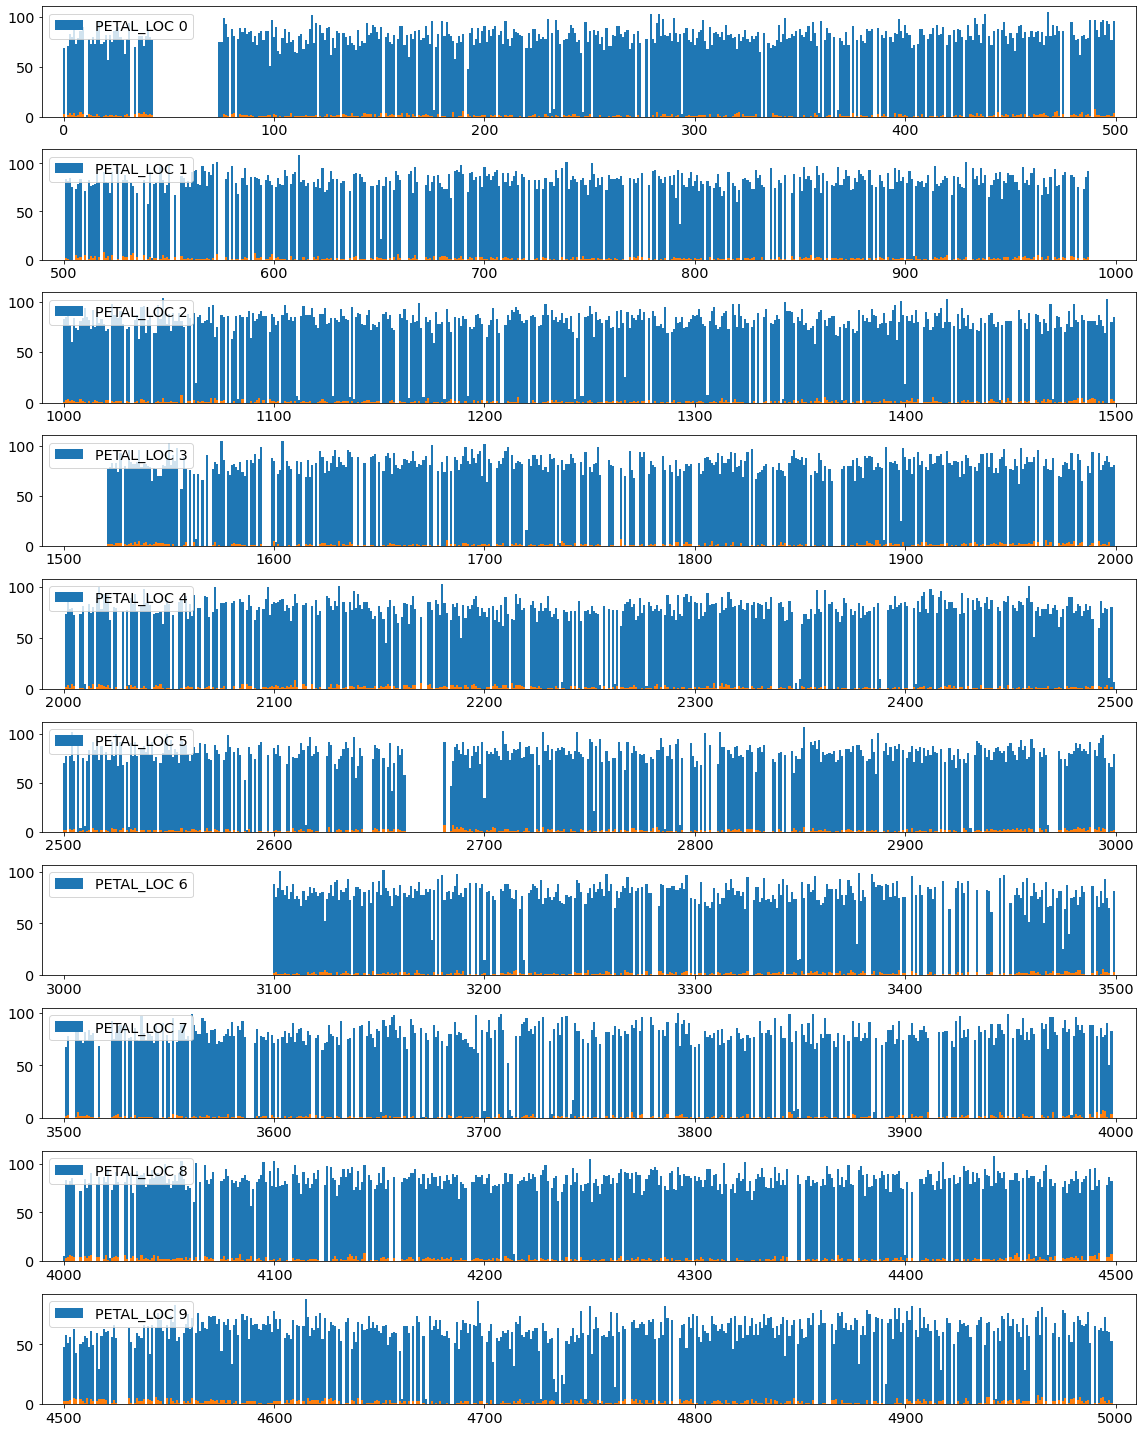

In [28]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (cat['FIBER']>fiber_min) & (cat['FIBER']<fiber_max)
    mask &= (~np.in1d(cat['FIBER'], bad_fibers2))
    ax[index].hist(cat['FIBER'][mask], 500, range=(fiber_min, fiber_max), label='PETAL_LOC {}'.format(index))
    ax[index].hist(cat['FIBER'][mask & (~mask_quality)], 500, range=(fiber_min, fiber_max))
    ax[index].set_xlim(fiber_min-10, fiber_max+10)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

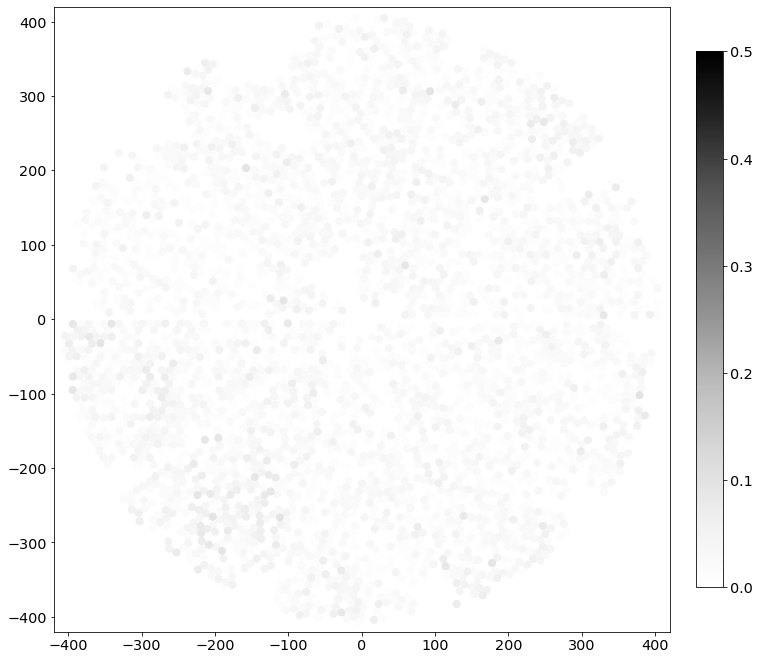

In [30]:
mask = fiberstats['n_tot']>30
mask &= (~np.in1d(fiberstats['FIBER'], bad_fibers2))

plt.figure(figsize=(12, 11.5))
plt.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=fiberstats['frac_fail'][mask],
            s=50, vmin=0, vmax=0.5, cmap='Greys')
plt.axis([-420, 420, -420, 420])
plt.colorbar(fraction=0.04, pad=0.04)
# plt.axis('off')
plt.show()

In [32]:
bad_fibers2

array([   1,   10,   32,   43,   44,   45,   46,   47,   48,   50,   51,
         52,   53,   54,   55,   56,   57,   58,   59,   60,   61,   62,
         63,   64,   65,   66,   67,   68,   69,   70,   71,   72,   79,
        132,  191,  237,  251,  272,  276,  386,  445,  458,  478,  500,
        524,  539,  551,  552,  579,  581,  588,  634,  637,  654,  661,
        663,  669,  670,  671,  677,  720,  736,  774,  782,  817,  839,
        842,  848,  849,  862,  885,  921,  931,  962,  964,  984,  988,
        989,  990,  991,  992,  993,  995,  997,  998,  999, 1032, 1033,
       1151, 1158, 1159, 1225, 1331, 1332, 1374, 1379, 1407, 1408, 1439,
       1447, 1452, 1453, 1500, 1501, 1502, 1504, 1505, 1506, 1507, 1508,
       1509, 1510, 1511, 1512, 1513, 1514, 1515, 1516, 1517, 1518, 1519,
       1559, 1570, 1592, 1673, 1676, 1704, 1757, 1764, 1869, 1971, 1972,
       2006, 2007, 2023, 2026, 2027, 2029, 2042, 2051, 2057, 2112, 2116,
       2123, 2124, 2135, 2168, 2169, 2183, 2260, 22

In [31]:
np.savetxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', bad_fibers2, fmt='%s')